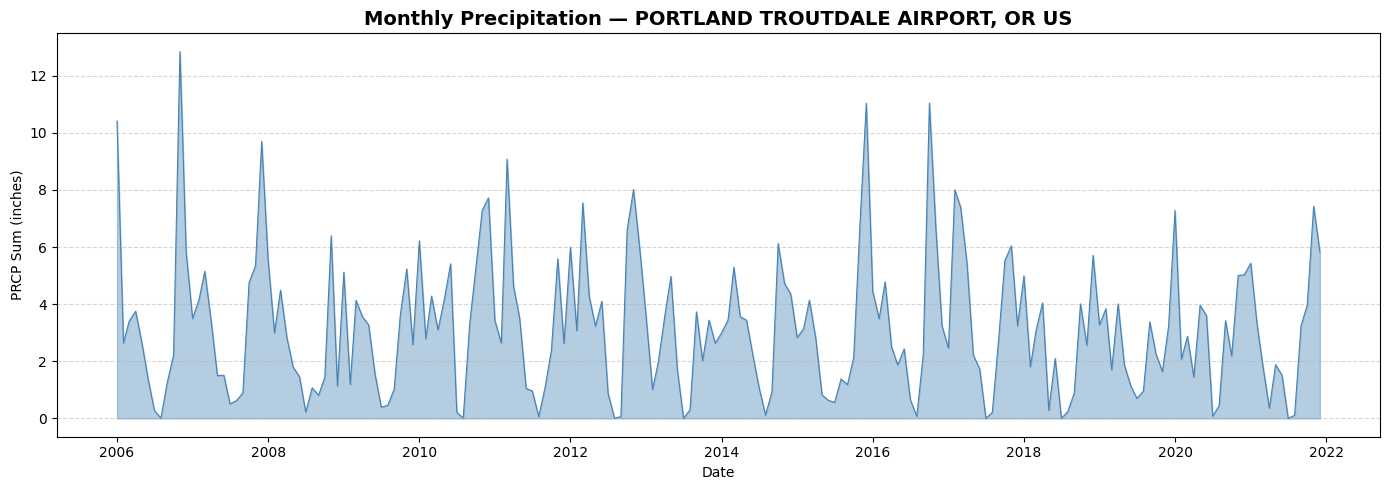


Station plotted: PORTLAND TROUTDALE AIRPORT, OR US (72698524242)


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

def plot_annual_prcp_random_station():
    df = pd.read_csv("oregon_weather_1970_2021.csv", low_memory=False)

    # Parse DATE
    df['DATE'] = pd.to_datetime(df['DATE'])
    df['YEAR_MONTH'] = df['DATE'].dt.to_period('M')

    # Replace missing PRCP values (99.99) with NaN
    df['PRCP'] = pd.to_numeric(df['PRCP'], errors='coerce')
    df.loc[df['PRCP'] == 99.99, 'PRCP'] = float('nan')

    # Pick a random station
    random_station = df['STATION'].dropna().unique()
    chosen = np.random.choice(random_station)
    station_df = df[df['STATION'] == chosen].copy()
    station_name = station_df['NAME'].iloc[0]

    # Sum PRCP per month
    monthly = (
        station_df.groupby('YEAR_MONTH')['PRCP']
        .sum()
        .reset_index()
    )
    monthly['YEAR_MONTH'] = monthly['YEAR_MONTH'].dt.to_timestamp()
    monthly = monthly.sort_values('YEAR_MONTH')

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(monthly['YEAR_MONTH'], monthly['PRCP'], alpha=0.4, color='steelblue')
    ax.plot(monthly['YEAR_MONTH'], monthly['PRCP'], color='steelblue', linewidth=0.8)

    ax.set_title(f'Monthly Precipitation — {station_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('PRCP Sum (inches)')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('prcp_plot.png', dpi=150)
    plt.show()
    print(f"\nStation plotted: {station_name} ({chosen})")

if __name__ == '__main__':
    plot_annual_prcp_random_station()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, r2_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load merged data ──────────────────────────────────────────────────
df = pd.read_csv('oregon_fires_weather_merged.csv', parse_dates=['report_date'])

# ── Features ──────────────────────────────────────────────────────────
features = ['TEMP','MAX','MIN','TEMP_RANGE','DEWP','VPD_PROXY',
            'WDSP','MXSPD','PRCP','PRCP_30DAY','MONTH','DOY','FIRE_SEASON']

df_model = df[features + ['total_acres']].dropna()
print(f"Modeling rows: {len(df_model):,}")

X = df_model[features]
y_size = df_model['total_acres']

# ── Fire size categories for classification ───────────────────────────
# Class 0: small (< 10 acres), Class 1: medium (10–100), Class 2: large (100+)

def size_class(acres):
    if acres < 10:    return 0
    elif acres < 100: return 1
    else:             return 2

df_model['SIZE_CLASS'] = df_model['total_acres'].apply(size_class)
print("\nFire size class distribution:")
print(df_model['SIZE_CLASS'].value_counts().sort_index()
      .rename({0:'Small (<10 ac)', 1:'Medium (10-100 ac)', 2:'Large (100+ ac)'}))

y_class = df_model['SIZE_CLASS']
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
        X, y_class, y_size, test_size=0.2, random_state=42
    )
print("\n── Training Classification Model ──")
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, yc_train)
yc_pred = clf.predict(X_test)

print(classification_report(yc_test, yc_pred,
      target_names=['Small','Medium','Large']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Small','Medium','Large'],
            yticklabels=['Small','Medium','Large'],
            cmap='Blues')
axes[0].set_title('Classification: Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importance - classifier
feat_imp_c = pd.Series(clf.feature_importances_, index=features).sort_values()
feat_imp_c.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Classification: Feature Importance')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.savefig('classification_results.png', dpi=150)
plt.show()
print("Saved classification_results.png")
print("\n── Training Regression Model ──")

# Log transform acres (highly skewed)
yr_train_log = np.log1p(yr_train)
yr_test_log  = np.log1p(yr_test)

reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X_train, yr_train_log)
yr_pred_log = reg.predict(X_test)
yr_pred     = np.expm1(yr_pred_log)

rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2   = r2_score(yr_test_log, yr_pred_log)
print(f"RMSE: {rmse:.2f} acres")
print(f"R²  : {r2:.3f} (on log scale)")

# Regression plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted
axes[0].scatter(np.log1p(yr_test), yr_pred_log, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 10], [0, 10], 'r--')
axes[0].set_xlabel('Actual log(acres)')
axes[0].set_ylabel('Predicted log(acres)')
axes[0].set_title(f'Regression: Actual vs Predicted (R²={r2:.3f})')

# Feature importance - regressor
feat_imp_r = pd.Series(reg.feature_importances_, index=features).sort_values()
feat_imp_r.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Regression: Feature Importance')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.savefig('regression_results.png', dpi=150)
plt.show()
print("Saved regression_results.png")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from torch_geometric.data import Data

COLUMNS = ['id','year','date','county','lat','lon','acres_final','acres_protect',
           'fuel_model','fuel_desc','cause','incident_id','unit_label','unit_name',
           'trs','stn_lat','stn_lon','temp_max','temp_min','dewpt_max','dewpt_min',
           'wind_max','wind_min','precip_am','precip_pm','ffmc_delta','bui_delta',
           'fire_danger','month','doy','legacy_id']

df = pd.read_csv('fires.csv', names=COLUMNS)

# --- Encode categoricals ---
fuel_enc = pd.get_dummies(df['fuel_model'])   # F, G, X
cause_enc = pd.get_dummies(df['cause'])

# --- Cyclic time encoding ---
df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365)

# --- Build node features ---
feat_cols = ['doy_sin','doy_cos','lat','lon',
             'temp_max','temp_min','wind_max','wind_min',
             'precip_am','precip_pm','ffmc_delta','bui_delta']
X = pd.concat([df[feat_cols], fuel_enc, cause_enc], axis=1).values

# --- Spatial edges via BallTree (haversine, ~10km radius) ---
coords_rad = np.radians(df[['lat','lon']].values)
tree = BallTree(coords_rad, metric='haversine')
RADIUS_KM = 10
indices = tree.query_radius(coords_rad, r=RADIUS_KM / 6371)

src, dst = [], []
for i, neighbors in enumerate(indices):
    for j in neighbors:
        if i != j:
            src.append(i); dst.append(j)

edge_index = torch.tensor([src, dst], dtype=torch.long)
x = torch.tensor(X, dtype=torch.float)
y = torch.tensor(np.log1p(df['acres_final'].values), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, y=y)

import torch
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, GATConv
from torch_geometric.data import HeteroData

# Node feature construction per fire event:
# x = [sin(doy), cos(doy), lat, lon, temp_max, temp_min,
#      humidity_max, humidity_min, wind_max, wind_min,
#      precip, fuel_emb(3d), cause_emb(4d)]
# → ~18 dimensional input

class WildfireGNN(torch.nn.Module):
    def __init__(self, in_dim=18, hidden=64, out_dim=1):
        super().__init__()
        # Layer 1: aggregate from spatial + temporal neighbors
        self.conv1 = GATConv(in_dim, hidden, heads=4, concat=False)
        # Layer 2: higher-order aggregation
        self.conv2 = GATConv(hidden, hidden, heads=4, concat=False)
        # Prediction head (e.g., predict log acres burned)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(hidden, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, out_dim)
        )

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.head(x)